In [1]:
import numpy as np
import json
import torch
import torch.nn as nn
from pathlib import Path
from matplotlib import pyplot as plt

In [2]:
from src.utils.schedulers import WarmupInvRsqrtLR, WarmupCosineDecayLR, WarmupCosineAnnealingWarmRestarts
from src.models.model_utilizer import update_optimizer_simple

In [3]:
config_dir = Path("./src/config/")

model_config_path = config_dir / "base-model-config.json"
assert model_config_path.exists(), f"Config not found: {model_config_path}"
with open(model_config_path, "r") as f:
    model_config = json.load(f)

In [4]:
optimizer = update_optimizer_simple(
    net = nn.Linear(10, 10),
    optim = model_config['solver_type'],
    lr=model_config['base_lr'],
    decay=model_config['weight_decay']
    )

In [5]:
if bool(model_config['scheduler_on']):
    warmup_steps = model_config['scheduler_warmup_steps']
    
    schedulers = {}
    
    schedulers['CosineAnnealingLR'] = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=model_config['scheduler_T_max'],
        eta_min=model_config['scheduler_eta_min']
        )
    
    schedulers['CosineAnnealingWarmRestarts'] = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, 
        T_0=model_config['scheduler_T_0'],
        T_mult=model_config['scheduler_T_mult'],
        eta_min=model_config['scheduler_eta_min']
        )
    
    schedulers['WarmupCosineAnnealing'] = WarmupCosineAnnealingWarmRestarts(
        optimizer,
        lr_max=model_config['base_lr'],
        warmup_steps=warmup_steps,
        T_0=model_config['scheduler_T_0'],
        T_mult=model_config['scheduler_T_mult'],
        eta_min=model_config['scheduler_eta_min'],
        restart_flag=False
        )
    
    schedulers['WarmupCosineAnnealingWarmRestarts'] = WarmupCosineAnnealingWarmRestarts(
        optimizer,
        lr_max=model_config['base_lr'],
        warmup_steps=warmup_steps,
        T_0=model_config['scheduler_T_0'],
        T_mult=model_config['scheduler_T_mult'],
        eta_min=model_config['scheduler_eta_min'],
        restart_flag=True
        )
    
    schedulers['WarmupInvRsqrtLR'] = WarmupInvRsqrtLR(
        optimizer,
        lr_max=model_config['base_lr'],
        warmup_steps=warmup_steps
        )
    
    schedulers['WarmupCosineDecayLR'] = WarmupCosineDecayLR(
        optimizer,
        lr_max=model_config['base_lr'],
        warmup_steps=warmup_steps,
        decay_rate=0.1,
        eta_min=model_config['base_lr'] / 10
        )

In [7]:
import warnings
warnings.filterwarnings("ignore", message=".*Detected call of `lr_scheduler.step\(\)` before `optimizer.step\(\)`.*")


batch_size = model_config['batch_size']
train_dataset_size = 36_000
batch_num = train_dataset_size // batch_size

if model_config['scheduler_mode'] == 'batch':
    total_steps = model_config['epochs'] * batch_num
elif model_config['scheduler_mode'] == 'epoch':
    total_steps = model_config['epochs']
else:
    raise NotImplementedError(f"Scheduler MODE not supported: {model_config['scheduler_mode']}")


histories = {}
for scheduler_name, scheduler_val in schedulers.items():
    lrs = []
    for _ in range(total_steps):
        lrs.append(scheduler_val.get_last_lr()[0])
        scheduler_val.step()
    histories[scheduler_name] = lrs

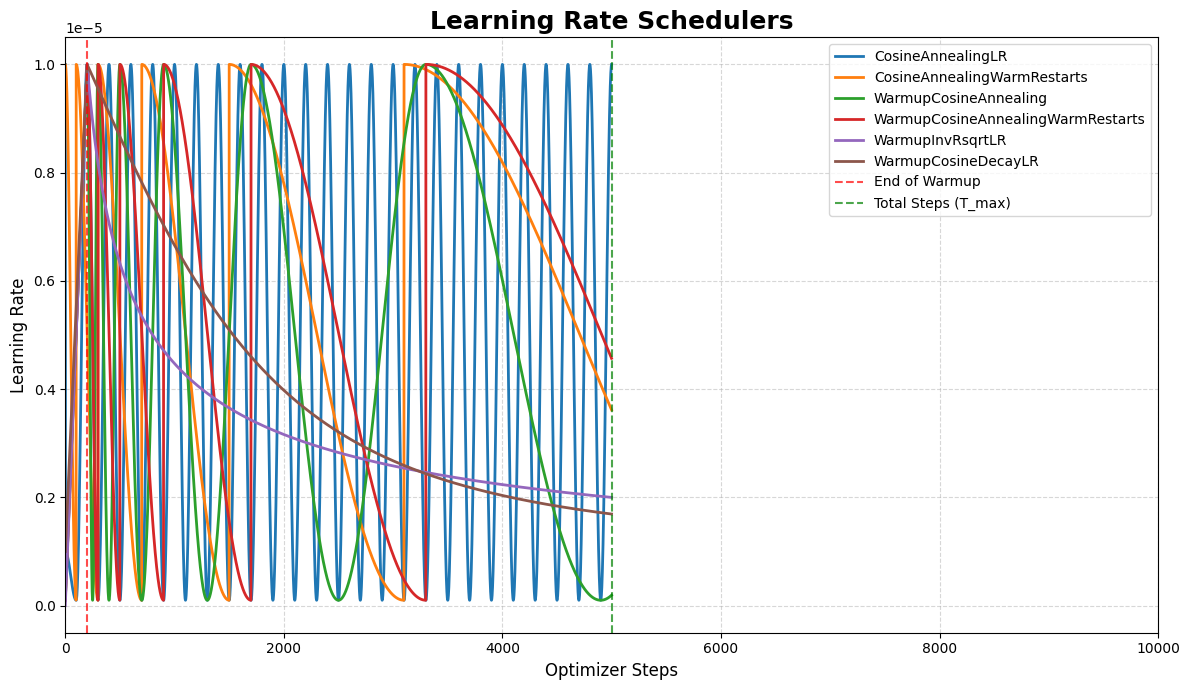

In [8]:
plt.figure(figsize=(12, 7))
for name, lrs in histories.items():
    plt.plot(lrs, label=name, linewidth=2)
    
plt.axvline(x=warmup_steps, color='r', linestyle='--', alpha=0.7, label='End of Warmup')
plt.axvline(x=total_steps, color='g', linestyle='--', alpha=0.7, label='Total Steps (T_max)')

plt.title("Learning Rate Schedulers", fontsize=18, fontweight='bold')
plt.xlabel("Optimizer Steps", fontsize=12)
plt.ylabel("Learning Rate", fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([0*warmup_steps, 50*warmup_steps])
plt.tight_layout()
plt.show()